# Import libraries and functions

In [1]:
import sys
import os
import pandas as pd

print(os.getcwd())
sys.path.insert(0, os.path.abspath(".."))

from create_db.db_connection import get_engine, get_connection

/Users/giakhanh/Desktop/AIDE/Projects/home_credit_risk/notebooks


# List all raw tables

In [20]:
RAW_TABLES = [
    "application_train",
    "application_test",
    "bureau",
    "bureau_balance",
    "previous_application",
    "pos_cash_balance",
    "installments_payments",
    "credit_card_balance",
]

# EDA raw layer

In [5]:
schema_name = "raw"

## Create DataFrame for each table

In [2]:
def create_df(table_name):
    engine = get_engine(database="home_credit")
    query = f"""
        select *
        from {schema_name}.{table_name}
        ;
    """
    return pd.read_sql(query, engine)

In [32]:
dfs = {}

for table in RAW_TABLES:
    print(f"Creating dataframe for {table}...")
    dfs[table] = create_df(table)

Creating dataframe for application_train...
Creating dataframe for application_test...
Creating dataframe for bureau...
Creating dataframe for bureau_balance...
Creating dataframe for previous_application...
Creating dataframe for pos_cash_balance...
Creating dataframe for installments_payments...
Creating dataframe for credit_card_balance...


In [33]:
dfs["application_train"]

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,None,None,None,None,None,None
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Analyze

## Profiling function

In [91]:
def profile_column(df):
    result = []

    for col in df.columns:
        series = df[col]

        # numeric test
        numeric = pd.to_numeric(series, errors = "coerce")
        numeric_ratio = numeric.notnull().mean()

        # datetime test
        datetime = pd.to_datetime(series, errors = "coerce")
        datetime_ratio = datetime.notnull().mean()

        result.append({
            "column" : col,
            "non null ratio" : series.notnull().mean().round(2),
            "unique" : series.nunique(),
            "numneric_ratio" : numeric_ratio.round(2),
            "datetime_ratio" : datetime_ratio.round(2),
            "sample_values": ", ".join(map(str, series.dropna().unique()[:5]))
        })

    return pd.DataFrame(result)

## Write to txt function

In [16]:
def write_to_txt(profile_df, file_path):
    with open(file_path, "w") as file:
        file.write(profile_df.to_string(index = False))

## Application train table

In [93]:
profile_df = profile_column(dfs["application_train"])
write_to_txt(profile_df, "application_train.txt")

/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5

## Application test

In [94]:
write_to_txt(profile_column(dfs["application_test"]), "application_test.txt")

/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5

## Bureau

In [95]:
profile_df = profile_column(dfs["bureau"])
write_to_txt(profile_df, "bureau.txt")

/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5

In [104]:
for column in dfs["bureau"].columns:
    print(f"- name: {column}\n  description:\n")

- name: sk_id_curr
  description:

- name: sk_id_bureau
  description:

- name: credit_active
  description:

- name: credit_currency
  description:

- name: days_credit
  description:

- name: credit_day_overdue
  description:

- name: days_credit_enddate
  description:

- name: days_enddate_fact
  description:

- name: amt_credit_max_overdue
  description:

- name: cnt_credit_prolong
  description:

- name: amt_credit_sum
  description:

- name: amt_credit_sum_debt
  description:

- name: amt_credit_sum_limit
  description:

- name: amt_credit_sum_overdue
  description:

- name: credit_type
  description:

- name: days_credit_update
  description:

- name: amt_annuity
  description:



## Bureau balance

In [105]:
write_to_txt(profile_column(dfs["bureau_balance"]), "bureau_balance.txt")

/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")


In [106]:
for column in dfs["bureau_balance"].columns:
    print(f"- name: {column}\n  description:\n")

- name: sk_id_bureau
  description:

- name: months_balance
  description:

- name: status
  description:



## Previous application

In [107]:
write_to_txt(profile_column(dfs["previous_application"]), "previous_application.txt")

/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5

In [109]:
count = 0

for column in dfs["previous_application"].columns:
    count += 1
    print(f"- name: {column}\n  description:\n")

print(count)

- name: sk_id_prev
  description:

- name: sk_id_curr
  description:

- name: name_contract_type
  description:

- name: amt_annuity
  description:

- name: amt_application
  description:

- name: amt_credit
  description:

- name: amt_down_payment
  description:

- name: amt_goods_price
  description:

- name: weekday_appr_process_start
  description:

- name: hour_appr_process_start
  description:

- name: flag_last_appl_per_contract
  description:

- name: nflag_last_appl_in_day
  description:

- name: rate_down_payment
  description:

- name: rate_interest_primary
  description:

- name: rate_interest_privileged
  description:

- name: name_cash_loan_purpose
  description:

- name: name_contract_status
  description:

- name: days_decision
  description:

- name: name_payment_type
  description:

- name: code_reject_reason
  description:

- name: name_type_suite
  description:

- name: name_client_type
  description:

- name: name_goods_category
  description:

- name: name_portfol

## Pos cash balance table

In [110]:
write_to_txt(profile_column(dfs["pos_cash_balance"]), "pos_cash_balance.txt")

/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5

In [111]:
count = 0

for column in dfs["pos_cash_balance"].columns:
    count += 1
    print(f"- name: {column}\n  description:\n")

print(count)

- name: sk_id_prev
  description:

- name: sk_id_curr
  description:

- name: months_balance
  description:

- name: cnt_instalment
  description:

- name: cnt_instalment_future
  description:

- name: name_contract_status
  description:

- name: sk_dpd
  description:

- name: sk_dpd_def
  description:

8


## Installments payments table

In [112]:
write_to_txt(profile_column(dfs["installments_payments"]), "installments_payments.txt")

/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5

In [113]:
count = 0

for column in dfs["installments_payments"].columns:
    count += 1
    print(f"- name: {column}\n  description:\n")

print(count)

- name: sk_id_prev
  description:

- name: sk_id_curr
  description:

- name: num_instalment_version
  description:

- name: num_instalment_number
  description:

- name: days_instalment
  description:

- name: days_entry_payment
  description:

- name: amt_instalment
  description:

- name: amt_payment
  description:

8


## Credit card balance table

In [114]:
write_to_txt(profile_column(dfs["credit_card_balance"]), "credit_card_balance.txt")

/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_39939/1834115527.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime = pd.to_datetime(series, errors = "coerce")
/var/folders/tx/zn_n1b0j357d3fvwq5

In [115]:

count = 0

for column in dfs["credit_card_balance"].columns:
    count += 1
    print(f"- name: {column}\n  description:\n")

print(count)

- name: sk_id_prev
  description:

- name: sk_id_curr
  description:

- name: months_balance
  description:

- name: amt_balance
  description:

- name: amt_credit_limit_actual
  description:

- name: amt_drawings_atm_current
  description:

- name: amt_drawings_current
  description:

- name: amt_drawings_other_current
  description:

- name: amt_drawings_pos_current
  description:

- name: amt_inst_min_regularity
  description:

- name: amt_payment_current
  description:

- name: amt_payment_total_current
  description:

- name: amt_receivable_principal
  description:

- name: amt_recivable
  description:

- name: amt_total_receivable
  description:

- name: cnt_drawings_atm_current
  description:

- name: cnt_drawings_current
  description:

- name: cnt_drawings_other_current
  description:

- name: cnt_drawings_pos_current
  description:

- name: cnt_instalment_mature_cum
  description:

- name: name_contract_status
  description:

- name: sk_dpd
  description:

- name: sk_dpd_def


# 1. EDA the final data on mart

In [119]:
schema_name = "marts"

In [120]:
df = create_df("mart_application_train")
df

,sk_id_curr,target,contract_type,gender_code,owns_car_flag,owns_realty_flag,children_count,family_member_count,family_status,accompany_type,...,previous_total_cc_demand_month_count,flag_has_previous_refused_application,flag_has_previous_canceled_application,flag_has_previous_approved_application,flag_has_previous_late_payment_history,flag_has_previous_pos_cash_dpd_history,flag_has_previous_pos_cash_dpd_def_history,flag_has_previous_cc_dpd_history,flag_has_previous_cc_dpd_def_history,flag_has_previous_cc_demand_history
0,284594,0,Cash loans,F,N,N,0,2.0,Married,Unaccompanied,...,0.0,1,1,1,0,0,0,0,0,0
1,284605,0,Cash loans,F,N,Y,0,1.0,Single / not married,Family,...,0.0,1,1,1,1,0,0,0,0,0
2,284611,0,Cash loans,M,Y,Y,1,3.0,Married,Unaccompanied,...,0.0,0,1,1,0,0,0,0,0,0
3,284977,0,Cash loans,M,N,Y,2,4.0,Married,Unaccompanied,...,0.0,1,1,1,0,0,0,0,0,0
4,285021,0,Revolving loans,F,N,Y,0,2.0,Married,Family,...,0.0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,284531,1,Cash loans,M,N,Y,1,3.0,Civil marriage,Unaccompanied,...,0.0,0,1,1,0,0,0,0,0,0
307507,284556,1,Cash loans,M,N,Y,2,4.0,Married,Unaccompanied,...,0.0,1,0,1,0,0,0,0,0,0
307508,284558,0,Cash loans,F,N,Y,0,1.0,Widow,Unaccompanied,...,0.0,0,1,1,1,0,0,0,0,0
307509,284569,0,Cash loans,F,Y,Y,1,3.0,Married,Unaccompanied,...,0.0,0,0,1,0,0,0,0,0,0


In [121]:
df.memory_usage(deep=True).sum() / 1024**2

873.3938302993774

## Check columns

In [122]:
# Display basic information about the dataset
print("BASIC DATASET INFORMATION")
print("=" * 50)
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nTARGET VARIABLE INFORMATION")
print("=" * 50)
print(df['target'].value_counts())
print(f"\nPercentage of customers with payment difficulties: {df['target'].mean():.2%}")

BASIC DATASET INFORMATION
Total rows: 307,511
Total columns: 268
Memory usage: 873.39 MB

TARGET VARIABLE INFORMATION
target
0    282686
1     24825
Name: count, dtype: int64

Percentage of customers with payment difficulties: 8.07%


In [22]:
with open("columns.txt", "w") as file:
    file.write("\n".join(df.columns))

## General Information

In [123]:
df.shape

(307511, 268)

In [140]:
# Quick separation into categorical and continuous
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
continuous_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("\nContinuous columns:", continuous_cols)


Categorical columns: ['contract_type', 'gender_code', 'owns_car_flag', 'owns_realty_flag', 'family_status', 'accompany_type', 'income_type', 'education_type', 'housing_type', 'occupation_type', 'organization_type', 'application_weekday', 'fondkapremont_mode', 'housetype_mode', 'wallsmaterial_mode', 'emergency_state_mode']

Continuous columns: ['sk_id_curr', 'target', 'children_count', 'family_member_count', 'income_total_amt', 'credit_amt', 'annuity_amt', 'goods_price_amt', 'region_population_relative', 'region_rating_client', 'region_rating_client_with_city', 'application_hour', 'days_birth', 'days_employed', 'days_registration', 'days_id_publish', 'days_last_phone_change', 'own_car_age', 'flag_mobile', 'flag_emp_phone', 'flag_work_phone', 'flag_cont_mobile', 'flag_phone', 'flag_email', 'reg_region_not_live_region', 'reg_region_not_work_region', 'live_region_not_work_region', 'reg_city_not_live_city', 'reg_city_not_work_city', 'live_city_not_work_city', 'ext_source_1', 'ext_source_2'

## Target Analysis

In [126]:
df["target"].value_counts(normalize=True)

target
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Ohhh imbalance

## Check duplicate

In [12]:
df.duplicated().sum()

0

## Missing analysis

In [132]:
# =========================
# 1. Analyze missing data
# =========================
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

# =========================
# 2. Create base DataFrame
# =========================
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percent.values,
})

# =========================
# 3. Identify column type
# =========================
missing_df['Type'] = missing_df['Column'].apply(
    lambda x: 'Categorical' if df[x].dtype == 'object' else 'Numerical'
)

# =========================
# 4. Add missing split columns
# =========================
missing_df['Missing_Categorical'] = missing_df.apply(
    lambda row: row['Missing_Count'] if row['Type'] == 'Categorical' else 0,
    axis=1
)

missing_df['Missing_Numerical'] = missing_df.apply(
    lambda row: row['Missing_Count'] if row['Type'] == 'Numerical' else 0,
    axis=1
)

# =========================
# 5. Filter + sort
# =========================
missing_df = missing_df[missing_df['Missing_Count'] > 0] \
                .sort_values('Missing_Percentage', ascending=False)

# =========================
# 6. Summary stats
# =========================
total_cols = df.shape[1]
missing_cols = len(missing_df)

num_cat_total = len(df.select_dtypes(include=['object']).columns)
num_num_total = len(df.select_dtypes(include=['int64', 'float64']).columns)

num_cat_missing = missing_df[missing_df['Type'] == 'Categorical'].shape[0]
num_num_missing = missing_df[missing_df['Type'] == 'Numerical'].shape[0]

# =========================
# 7. Print report
# =========================
print("MISSING DATA ANALYSIS")
print("=" * 60)
print(f"Total columns: {total_cols}")
print(f"Columns with missing data: {missing_cols}")
print(f"Percentage of columns with missing data: {missing_cols/total_cols:.2%}")

print("\n--- COLUMN TYPE SUMMARY ---")
print(f"Total categorical columns: {num_cat_total}")
print(f"Total numerical columns: {num_num_total}")

print(f"Categorical columns with missing: {num_cat_missing}")
print(f"Numerical columns with missing: {num_num_missing}")

MISSING DATA ANALYSIS
Total columns: 268
Columns with missing data: 138
Percentage of columns with missing data: 51.49%

--- COLUMN TYPE SUMMARY ---
Total categorical columns: 16
Total numerical columns: 252
Categorical columns with missing: 6
Numerical columns with missing: 132


In [133]:
df[categorical_cols]

,contract_type,gender_code,owns_car_flag,owns_realty_flag,family_status,accompany_type,income_type,education_type,housing_type,occupation_type,organization_type,application_weekday,fondkapremont_mode,housetype_mode,wallsmaterial_mode,emergency_state_mode
0,Cash loans,F,N,N,Married,Unaccompanied,Working,Higher education,House / apartment,Laborers,Industry: type 3,TUESDAY,None,None,None,None
1,Cash loans,F,N,Y,Single / not married,Family,State servant,Secondary / secondary special,House / apartment,None,School,FRIDAY,None,None,None,None
2,Cash loans,M,Y,Y,Married,Unaccompanied,Commercial associate,Secondary / secondary special,House / apartment,Cooking staff,Business Entity Type 3,THURSDAY,reg oper account,block of flats,Mixed,No
3,Cash loans,M,N,Y,Married,Unaccompanied,Working,Secondary / secondary special,House / apartment,Drivers,Self-employed,SATURDAY,None,None,None,None
4,Revolving loans,F,N,Y,Married,Family,Commercial associate,Secondary / secondary special,House / apartment,Laborers,Self-employed,MONDAY,reg oper spec account,block of flats,Panel,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,Cash loans,M,N,Y,Civil marriage,Unaccompanied,Working,Secondary / secondary special,House / apartment,Laborers,Business Entity Type 3,SATURDAY,None,None,None,None
307507,Cash loans,M,N,Y,Married,Unaccompanied,Working,Secondary / secondary special,House / apartment,Laborers,Industry: type 3,MONDAY,None,None,None,None
307508,Cash loans,F,N,Y,Widow,Unaccompanied,Working,Secondary / secondary special,House / apartment,Accountants,Industry: type 3,SUNDAY,None,None,None,None
307509,Cash loans,F,Y,Y,Married,Unaccompanied,Commercial associate,Higher education,Rented apartment,Laborers,Industry: type 11,FRIDAY,None,None,None,None


In [134]:
missing_ratio = df.isnull().mean().sort_values(ascending=False)
missing_ratio.head(20)

previous_cc_avg_payment_ratio_mean    0.832497
previous_cc_min_payment_ratio_min     0.832497
previous_cc_max_utilization_max       0.749404
previous_cc_avg_utilization_mean      0.749404
previous_cc_max_dpd_def_max           0.746565
previous_cc_avg_balance_mean          0.746565
previous_cc_max_balance_max           0.746565
previous_cc_avg_limit_mean            0.746565
previous_cc_avg_dpd_mean              0.746565
previous_cc_max_dpd_max               0.746565
previous_cc_avg_dpd_def_mean          0.746565
bureau_avg_amt_annuity                0.739817
bureau_max_amt_annuity                0.739817
bureau_balance_max_dpd_severity       0.707796
commonarea_avg                        0.698723
commonarea_medi                       0.698723
commonarea_mode                       0.698723
nonlivingapartments_avg               0.694330
nonlivingapartments_medi              0.694330
nonlivingapartments_mode              0.694330
dtype: float64

In [135]:
high_missing = missing_ratio[missing_ratio > 0.7]
mid_missing = missing_ratio[(missing_ratio <= 0.7) & (missing_ratio > 0.3)]
low_missing = missing_ratio[missing_ratio <= 0.3]

print("High missing:", len(high_missing))
print("Mid missing:", len(mid_missing))
print("Low missing:", len(low_missing))

High missing: 14
Mid missing: 52
Low missing: 202


In [136]:
for col in high_missing.index[:10]:
    print(col)
    print(df.groupby(df[col].isnull())["target"].mean())
    print("------")

previous_cc_avg_payment_ratio_mean
previous_cc_avg_payment_ratio_mean
False    0.107942
True     0.075253
Name: target, dtype: float64
------
previous_cc_min_payment_ratio_min
previous_cc_min_payment_ratio_min
False    0.107942
True     0.075253
Name: target, dtype: float64
------
previous_cc_max_utilization_max
previous_cc_max_utilization_max
False    0.090059
True     0.077609
Name: target, dtype: float64
------
previous_cc_avg_utilization_mean
previous_cc_avg_utilization_mean
False    0.090059
True     0.077609
Name: target, dtype: float64
------
previous_cc_max_dpd_def_max
previous_cc_max_dpd_def_max
False    0.090384
True     0.077451
Name: target, dtype: float64
------
previous_cc_avg_balance_mean
previous_cc_avg_balance_mean
False    0.090384
True     0.077451
Name: target, dtype: float64
------
previous_cc_max_balance_max
previous_cc_max_balance_max
False    0.090384
True     0.077451
Name: target, dtype: float64
------
previous_cc_avg_limit_mean
previous_cc_avg_limit_mean
Fals

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

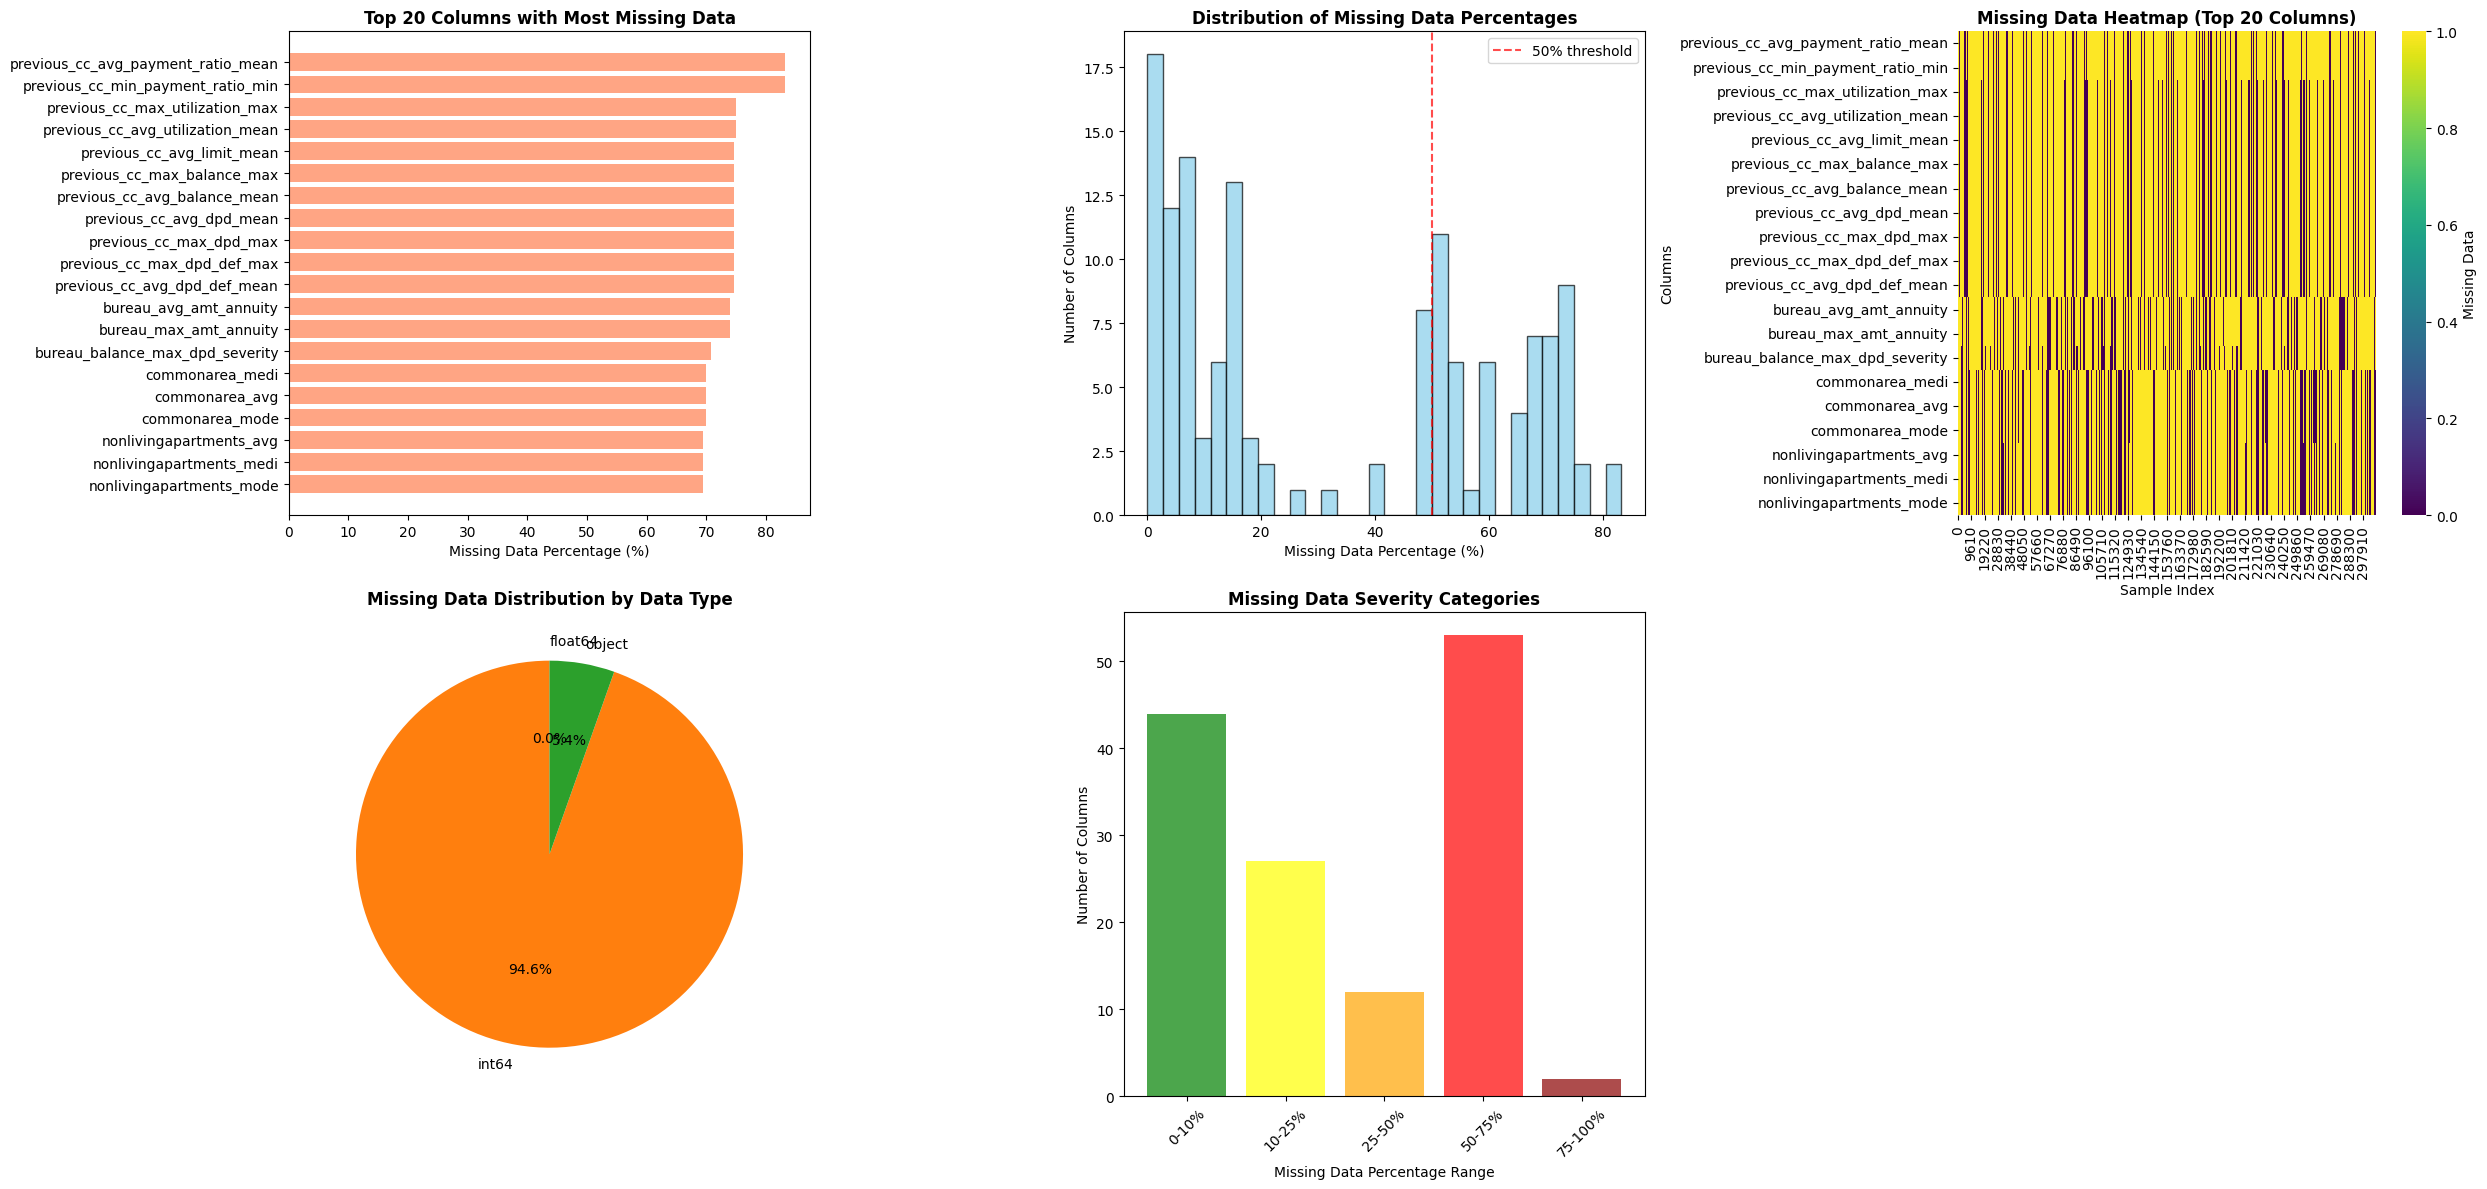


MISSING DATA INSIGHTS:
• 55 columns have more than 50% missing data
• 2 columns have more than 75% missing data
• Most missing data is in: previous_cc_avg_payment_ratio_mean (83.2%)
• Average missing data percentage: 33.2%


In [137]:
# Create comprehensive missing data visualization
plt.figure(figsize=(25, 12))

# Plot 1: Top 20 columns with most missing data
plt.subplot(2, 3, 1)
top_missing = missing_df.head(20)
plt.barh(range(len(top_missing)), top_missing['Missing_Percentage'], color='coral', alpha=0.7)
plt.yticks(range(len(top_missing)), top_missing['Column'])
plt.xlabel('Missing Data Percentage (%)')
plt.title('Top 20 Columns with Most Missing Data', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()

# Plot 2: Distribution of missing data percentages
plt.subplot(2, 3, 2)
plt.hist(missing_percent[missing_percent > 0], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Missing Data Percentage (%)')
plt.ylabel('Number of Columns')
plt.title('Distribution of Missing Data Percentages', fontsize=12, fontweight='bold')
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
plt.legend()

# Plot 3: Missing data heatmap for top 20 columns
plt.subplot(2, 3, 3)
top_20_cols = missing_df.head(20)['Column'].tolist()
missing_heatmap_data = df[top_20_cols].isnull()
sns.heatmap(missing_heatmap_data.T, cbar=True, yticklabels=True, cmap='viridis', 
            cbar_kws={'label': 'Missing Data'})
plt.title('Missing Data Heatmap (Top 20 Columns)', fontsize=12, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Columns')

# Plot 4: Missing data by data type
plt.subplot(2, 3, 4)
data_types = df.dtypes.value_counts()
missing_by_type = df.groupby(df.dtypes, axis=1).apply(lambda x: x.isnull().sum().sum())
plt.pie(missing_by_type.values, labels=data_types.index, autopct='%1.1f%%', startangle=90)
plt.title('Missing Data Distribution by Data Type', fontsize=12, fontweight='bold')


# Plot 6: Missing data severity categories
plt.subplot(2, 3, 5)
severity_categories = pd.cut(missing_percent[missing_percent > 0], 
                           bins=[0, 10, 25, 50, 75, 100], 
                           labels=['0-10%', '10-25%', '25-50%', '50-75%', '75-100%'])
severity_counts = severity_categories.value_counts().sort_index()
plt.bar(severity_counts.index, severity_counts.values, color=['green', 'yellow', 'orange', 'red', 'darkred'], alpha=0.7)
plt.xlabel('Missing Data Percentage Range')
plt.ylabel('Number of Columns')
plt.title('Missing Data Severity Categories', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Analysis and insights
print("\nMISSING DATA INSIGHTS:")
print("=" * 50)
print(f"• {len(missing_df[missing_df['Missing_Percentage'] > 50])} columns have more than 50% missing data")
print(f"• {len(missing_df[missing_df['Missing_Percentage'] > 75])} columns have more than 75% missing data")
print(f"• Most missing data is in: {missing_df.iloc[0]['Column']} ({missing_df.iloc[0]['Missing_Percentage']:.1f}%)")
print(f"• Average missing data percentage: {missing_percent[missing_percent > 0].mean():.1f}%")

## Univariate Analysis

In [40]:
def visualize_numerical_attribute(name_of_attribute: str, data: pd.DataFrame = df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram (bỏ KDE)
    sns.histplot(data[name_of_attribute], bins=20, color='skyblue', edgecolor='black', ax=ax1)
    ax1.set_title(f'Distribution of {name_of_attribute}', fontsize=14)
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')

    # Boxplot để kiểm tra outliers
    sns.boxplot(x=data[name_of_attribute], color='lightcoral', ax=ax2)
    ax2.set_title(f'Boxplot of {name_of_attribute}', fontsize=14)
    ax2.set_xlabel('')

    plt.tight_layout()
    plt.show()

In [41]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols

['sk_id_curr',
 'target',
 'children_count',
 'family_member_count',
 'income_total_amt',
 'credit_amt',
 'annuity_amt',
 'goods_price_amt',
 'region_population_relative',
 'region_rating_client',
 'region_rating_client_with_city',
 'application_hour',
 'days_birth',
 'days_employed',
 'days_registration',
 'days_id_publish',
 'days_last_phone_change',
 'own_car_age',
 'flag_mobile',
 'flag_emp_phone',
 'flag_work_phone',
 'flag_cont_mobile',
 'flag_phone',
 'flag_email',
 'reg_region_not_live_region',
 'reg_region_not_work_region',
 'live_region_not_work_region',
 'reg_city_not_live_city',
 'reg_city_not_work_city',
 'live_city_not_work_city',
 'ext_source_1',
 'ext_source_2',
 'ext_source_3',
 'apartments_avg',
 'basementarea_avg',
 'years_beginexpluatation_avg',
 'years_build_avg',
 'commonarea_avg',
 'elevators_avg',
 'entrances_avg',
 'floorsmax_avg',
 'floorsmin_avg',
 'landarea_avg',
 'livingapartments_avg',
 'livingarea_avg',
 'nonlivingapartments_avg',
 'nonlivingarea_avg',
 '

In [43]:
def visualize_all_numeric_attributes(df):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    n_cols = 2   # mỗi attribute có 2 biểu đồ (histogram + boxplot)
    n_rows = len(numeric_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))

    for i, col in enumerate(numeric_cols):
        # Histogram
        sns.histplot(df[col], bins=20, color='skyblue', edgecolor='black', ax=axes[i, 0])
        axes[i, 0].set_title(f'Distribution of {col}', fontsize=12)
        axes[i, 0].set_xlabel('')
        axes[i, 0].set_ylabel('Count')

        # Boxplot
        sns.boxplot(x=df[col], color='lightcoral', ax=axes[i, 1])
        axes[i, 1].set_title(f'Boxplot of {col}', fontsize=12)
        axes[i, 1].set_xlabel('')

    plt.tight_layout()
    plt.show()

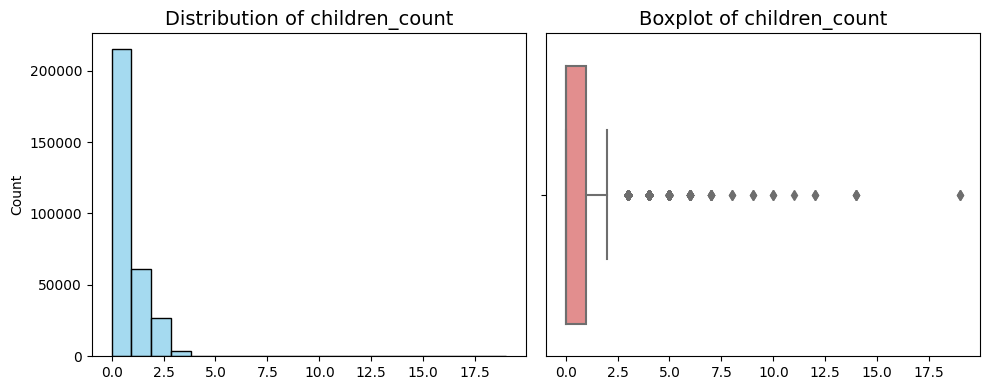

In [47]:
visualize_numerical_attribute("children_count")

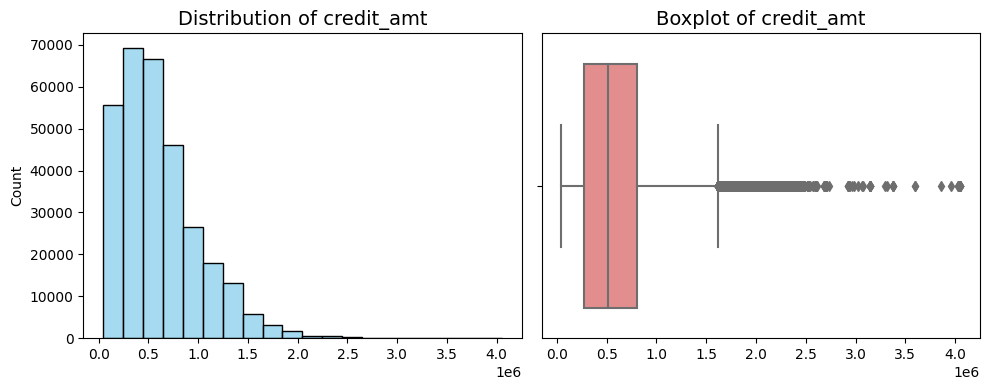

In [48]:
visualize_numerical_attribute("credit_amt")

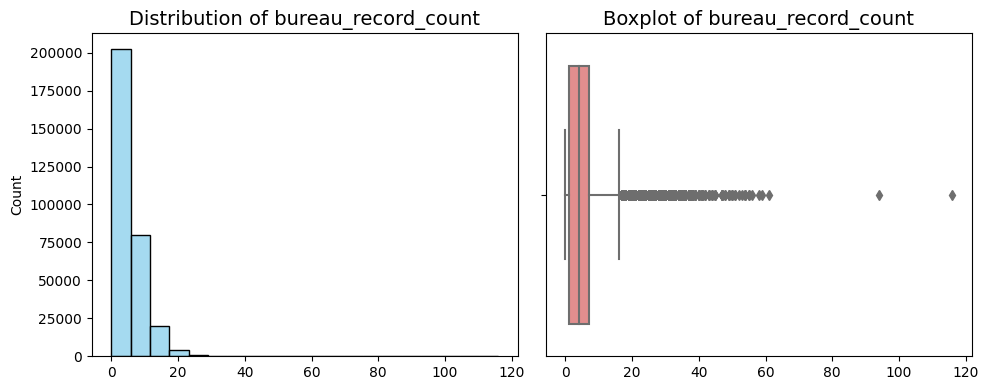

In [49]:
visualize_numerical_attribute("bureau_record_count")

## Feature understanding

### Correlation

In [13]:
corr = df.corr(numeric_only=True)["target"].sort_values(ascending=False)
corr.head(20)

target                                        1.000000
previous_cc_avg_utilization_mean              0.143841
previous_cc_max_utilization_max               0.111089
bureau_avg_days_credit                        0.089729
previous_cc_avg_balance_mean                  0.086693
days_birth                                    0.078239
previous_refused_ratio                        0.077671
bureau_min_days_credit                        0.075248
days_employed_clean                           0.074958
credit_to_goods_ratio                         0.069427
previous_cc_max_balance_max                   0.069336
bureau_avg_days_credit_update                 0.068927
previous_avg_credit_to_goods_ratio            0.065188
previous_avg_approved_to_application_ratio    0.065003
previous_refused_count                        0.064756
region_rating_client_with_city                0.060893
region_rating_client                          0.058899
flag_income_working                           0.057481
flag_has_p

The low result here means this is not linear correlation

In [ ]:
df.groupby("target")["bureau_record_count"].mean()

target
0    4.778464
1    4.613092
Name: bureau_record_count, dtype: float64

<Axes: xlabel='target', ylabel='bureau_record_count'>

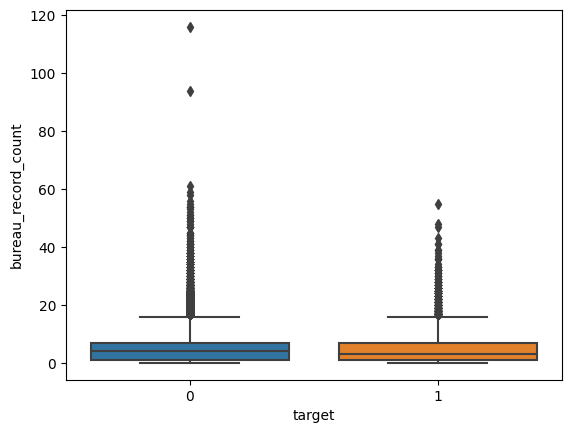

In [27]:
import seaborn as sns

sns.boxplot(x="target", y="bureau_record_count", data=df)

<Axes: xlabel='bureau_record_count', ylabel='Density'>

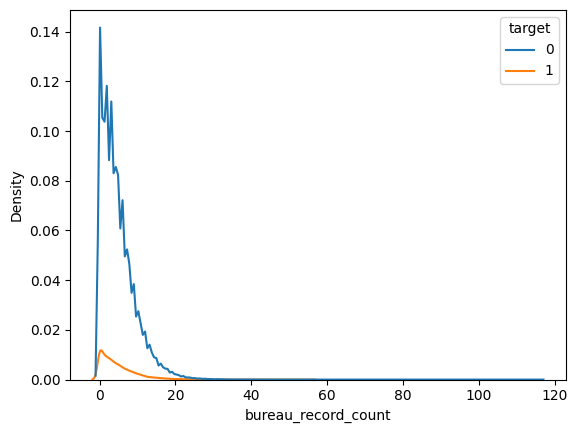

In [25]:
import seaborn as sns

sns.kdeplot(data=df, x="bureau_record_count", hue="target")

# Feature Engineering for Categorical Features

In [73]:
categorical_cols

['contract_type',
 'gender_code',
 'owns_car_flag',
 'owns_realty_flag',
 'family_status',
 'accompany_type',
 'income_type',
 'education_type',
 'housing_type',
 'occupation_type',
 'organization_type',
 'application_weekday',
 'fondkapremont_mode',
 'housetype_mode',
 'wallsmaterial_mode',
 'emergency_state_mode']

In [74]:
df[categorical_cols]

,contract_type,gender_code,owns_car_flag,owns_realty_flag,family_status,accompany_type,income_type,education_type,housing_type,occupation_type,organization_type,application_weekday,fondkapremont_mode,housetype_mode,wallsmaterial_mode,emergency_state_mode
0,Cash loans,M,Y,Y,Married,Unaccompanied,Commercial associate,Secondary / secondary special,House / apartment,Laborers,Business Entity Type 3,FRIDAY,reg oper account,block of flats,Panel,No
1,Cash loans,M,N,Y,Civil marriage,Unaccompanied,Working,Secondary / secondary special,House / apartment,Laborers,Business Entity Type 3,SATURDAY,None,None,None,None
2,Cash loans,M,N,Y,Married,Unaccompanied,Working,Secondary / secondary special,House / apartment,Laborers,Industry: type 3,MONDAY,None,None,None,None
3,Cash loans,F,N,Y,Widow,Unaccompanied,Working,Secondary / secondary special,House / apartment,Accountants,Industry: type 3,SUNDAY,None,None,None,None
4,Cash loans,F,Y,Y,Married,Unaccompanied,Commercial associate,Higher education,Rented apartment,Laborers,Industry: type 11,FRIDAY,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,Revolving loans,F,N,Y,Married,Unaccompanied,Commercial associate,Higher education,House / apartment,Core staff,Business Entity Type 3,MONDAY,None,None,Panel,No
307507,Cash loans,M,Y,Y,Married,Unaccompanied,Working,Secondary / secondary special,House / apartment,Low-skill Laborers,Other,MONDAY,None,None,None,None
307508,Cash loans,F,N,Y,Married,Unaccompanied,Working,Higher education,House / apartment,High skill tech staff,Other,SATURDAY,reg oper spec account,block of flats,Monolithic,No
307509,Cash loans,F,N,Y,Separated,Unaccompanied,Pensioner,Higher education,House / apartment,None,XNA,SATURDAY,None,block of flats,"Stone, brick",No


In [76]:
summary = []

for col in categorical_cols:
    total = len(df)
    missing = df[col].isnull().sum()
    missing_pct = missing / total * 100
    unique = df[col].nunique()
    
    top_ratio = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    
    summary.append({
        'column': col,
        'missing_%': round(missing_pct, 2),
        'n_unique': unique,
        'top_category_ratio': round(top_ratio, 3)
    })

summary_df = pd.DataFrame(summary).sort_values(by='missing_%', ascending=False)

print(summary_df)

                  column  missing_%  n_unique  top_category_ratio
12    fondkapremont_mode      68.39         4               0.684
14    wallsmaterial_mode      50.84         7               0.508
13        housetype_mode      50.18         3               0.502
15  emergency_state_mode      47.40         2               0.518
9        occupation_type      31.35        18               0.313
5         accompany_type       0.42         7               0.808
0          contract_type       0.00         2               0.905
1            gender_code       0.00         3               0.658
2          owns_car_flag       0.00         2               0.660
3       owns_realty_flag       0.00         2               0.694
4          family_status       0.00         6               0.639
6            income_type       0.00         8               0.516
7         education_type       0.00         5               0.710
8           housing_type       0.00         6               0.887
10     org

In [80]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    
    temp = df.copy()
    temp[col] = temp[col].fillna('Missing')
    
    stats = temp.groupby(col).agg(
        default_rate=('target', 'mean'),
        count=('target', 'count')
    )
    
    print(stats.sort_values(by='default_rate', ascending=False).head(10))


===== contract_type =====
                 default_rate   count
contract_type                        
Cash loans           0.083459  278232
Revolving loans      0.054783   29279

===== gender_code =====
             default_rate   count
gender_code                      
M                0.101419  105059
F                0.069993  202448
XNA              0.000000       4

===== owns_car_flag =====
               default_rate   count
owns_car_flag                      
N                  0.085002  202924
Y                  0.072437  104587

===== owns_realty_flag =====
                  default_rate   count
owns_realty_flag                      
N                     0.083249   94199
Y                     0.079616  213312

===== family_status =====
                      default_rate   count
family_status                             
Civil marriage            0.099446   29775
Single / not married      0.098077   45444
Separated                 0.081942   19770
Married                   0

## 📊 Categorical Feature Selection Using Target Mean, Count, and Missing Values

---

### 1. Evaluation Methodology

Categorical features are evaluated using three key criteria:

1. **Target Mean (default_rate)**  
   Measures how well a feature separates the target variable.

2. **Count (sample size)**  
   Ensures the observed patterns are reliable and not due to noise.

3. **Missing Values**  
   Determines whether missing data carries signal or reduces feature quality.

---

### 2. Interpretation Rules

#### Target Mean (Signal Strength)
- Large differences → strong feature  
- Small differences → weak feature  

#### Count (Reliability)
- High count → stable signal  
- Low count (<100) → unreliable, likely noise  

#### Missing Values
- Missing may contain useful signal  
- Very high missing rate (>50%) reduces usability  

---

## Feature-by-Feature Analysis

---

### ✅ Strong Features (Keep)

#### `occupation_type`

- Large gap: 0.17 → 0.07  
- High counts in key groups:
  - Laborers: 55k  
  - Drivers: 18k  

**Insight:**  
Strong and reliable separation of risk  

**Decision:**  
- Keep  
- Add missing flag  
- Apply target encoding  

---

#### `organization_type`

- Clear variation across industries  
- Some groups have sufficient counts  

**Insight:**  
Captures industry-level risk differences  

**Decision:**  
- Keep  
- Apply target encoding  
- Group rare categories  

---

#### `income_type`

- Clear separation among major groups  
- Rare categories show extreme values but low counts  

**Insight:**  
Main categories are informative and stable  

**Decision:**  
- Keep  
- Group rare categories  

---

#### `education_type`

- Strong separation: 0.109 → 0.018  
- Large counts  

**Insight:**  
Highly interpretable and stable  

**Decision:**  
- Keep  

---

#### `housing_type`

- Clear gap: 0.12 → 0.06  
- Large count in main category  

**Insight:**  
Despite skew, still provides meaningful signal  

**Decision:**  
- Keep  

---

### ⚠️ Medium Features (Optional)

#### `family_status`

- Moderate gap: 0.099 → 0.058  
- Large counts  

**Decision:**  
- Keep (optional)  

---

#### `contract_type`

- Moderate gap: 0.083 → 0.054  
- Stable counts  

**Decision:**  
- Keep (low priority)  

---

#### `owns_car_flag`

- Small gap: 0.085 → 0.072  
- Large counts  

**Decision:**  
- Optional (useful for tree models)  

---

### ❌ Weak Features (Drop)

#### `owns_realty_flag`

- Very small difference  

**Decision:**  
- Drop  

---

#### `application_weekday`

- Nearly identical values across categories  

**Decision:**  
- Drop  

---

#### `accompany_type`

- Highly imbalanced  
- Small groups are unreliable  

**Decision:**  
- Drop  

---

#### `gender_code`

- Contains rare category  
- Potential bias  

**Decision:**  
- Drop  

---

### ❌ High-Missing Features (Drop)

#### `fondkapremont_mode`
#### `housetype_mode`
#### `wallsmaterial_mode`
#### `emergency_state_mode`

**Observation:**
- Missing values have relatively high default rates  
- However, missing proportion is extremely large (>50%)

**Insight:**  
Missing carries signal but overall feature is not reliable  

**Decision:**  
- Drop all  

---

## Final Feature Selection

### ✅ Core Features

- occupation_type  
- organization_type  
- income_type  
- education_type  
- housing_type  

---

### ⚠️ Optional Features

- family_status  
- contract_type  
- owns_car_flag  

---

### ❌ Dropped Features

- gender_code  
- owns_realty_flag  
- accompany_type  
- application_weekday  
- fondkapremont_mode  
- housetype_mode  
- wallsmaterial_mode  
- emergency_state_mode  

---

## Key Takeaways

- Feature selection should prioritize **target mean separation**  
- Count is necessary to validate reliability  
- Missing values can be informative but must be evaluated carefully  

In summary:

- **Target mean = signal strength**  
- **Count = reliability**  
- **Missing = potential signal or noise depending on context**

--> For baseline model, I will keep all core features and optional features

# Feature Engineering for Numerical Features

In [141]:
df[continuous_cols].to_csv("continuous_col_df")

In [142]:
df[continuous_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sk_id_curr,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
target,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
children_count,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
family_member_count,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0
income_total_amt,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
...,...,...,...,...,...,...,...,...
flag_has_previous_pos_cash_dpd_history,307511.0,0.167282,0.373228,0.0,0.0,0.0,0.0,1.0
flag_has_previous_pos_cash_dpd_def_history,307511.0,0.124096,0.329692,0.0,0.0,0.0,0.0,1.0
flag_has_previous_cc_dpd_history,307511.0,0.040903,0.198065,0.0,0.0,0.0,0.0,1.0
flag_has_previous_cc_dpd_def_history,307511.0,0.032483,0.177280,0.0,0.0,0.0,0.0,1.0


In [143]:
# lấy các cột có missing
missing_cols = [col for col in continuous_cols if df[col].isnull().sum() > 0]

# loop qua từng cột
for col in missing_cols:
    print(f"\n===== COLUMN: {col} =====")
    
    temp = df.sort_values(by=col, na_position='first')[
        ['sk_id_curr', 'target', col]
    ]
    
    print(temp.head(10))  # xem 10 dòng đầu (toàn missing nếu có)


===== COLUMN: family_member_count =====
        sk_id_curr  target  family_member_count
20238       317181       0                  NaN
188460      148605       0                  NaN
74639       199445       0                  1.0
80941       437772       1                  1.0
80940       431516       0                  1.0
221745      308599       0                  1.0
80934       437331       0                  1.0
221747      308628       1                  1.0
80928       436707       0                  1.0
80927       436695       0                  1.0

===== COLUMN: annuity_amt =====
        sk_id_curr  target  annuity_amt
37488       243648       0          NaN
84289       203726       0          NaN
92656       159744       0          NaN
122316      187985       0          NaN
131193      163757       0          NaN
136855      377174       0          NaN
184617      364022       0          NaN
193683      340147       0          NaN
266034      157917       0          Na

In [144]:
missing = df[continuous_cols].isnull().sum()
missing_percent = missing / len(df) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
}).query('missing_count > 0').sort_values(by='missing_percent', ascending=False)

print(missing_df.to_string())

                                            missing_count  missing_percent
previous_cc_avg_payment_ratio_mean                 256002        83.249705
previous_cc_min_payment_ratio_min                  256002        83.249705
previous_cc_avg_utilization_mean                   230450        74.940409
previous_cc_max_utilization_max                    230450        74.940409
previous_cc_max_dpd_def_max                        229577        74.656516
previous_cc_avg_dpd_def_mean                       229577        74.656516
previous_cc_max_dpd_max                            229577        74.656516
previous_cc_avg_balance_mean                       229577        74.656516
previous_cc_max_balance_max                        229577        74.656516
previous_cc_avg_limit_mean                         229577        74.656516
previous_cc_avg_dpd_mean                           229577        74.656516
bureau_avg_amt_annuity                             227502        73.981744
bureau_max_amt_annuity   

In [145]:
missing.index.to_list()

['sk_id_curr',
 'target',
 'children_count',
 'family_member_count',
 'income_total_amt',
 'credit_amt',
 'annuity_amt',
 'goods_price_amt',
 'region_population_relative',
 'region_rating_client',
 'region_rating_client_with_city',
 'application_hour',
 'days_birth',
 'days_employed',
 'days_registration',
 'days_id_publish',
 'days_last_phone_change',
 'own_car_age',
 'flag_mobile',
 'flag_emp_phone',
 'flag_work_phone',
 'flag_cont_mobile',
 'flag_phone',
 'flag_email',
 'reg_region_not_live_region',
 'reg_region_not_work_region',
 'live_region_not_work_region',
 'reg_city_not_live_city',
 'reg_city_not_work_city',
 'live_city_not_work_city',
 'ext_source_1',
 'ext_source_2',
 'ext_source_3',
 'apartments_avg',
 'basementarea_avg',
 'years_beginexpluatation_avg',
 'years_build_avg',
 'commonarea_avg',
 'elevators_avg',
 'entrances_avg',
 'floorsmax_avg',
 'floorsmin_avg',
 'landarea_avg',
 'livingapartments_avg',
 'livingarea_avg',
 'nonlivingapartments_avg',
 'nonlivingarea_avg',
 '

In [146]:
skew_value = df[continuous_cols].skew().sort_values(ascending=False)
print(skew_value.to_string())

flag_document_12                                392.114779
flag_has_previous_cc_demand_history             392.114779
previous_total_cc_demand_month_count            392.114779
income_total_amt                                391.559654
bureau_avg_credit_max_overdue                   318.279892
bureau_max_credit_max_overdue                   265.926459
bureau_avg_credit_sum_overdue                   218.350874
previous_cc_min_payment_ratio_min               218.213148
income_per_child_adjusted                       213.662640
flag_document_10                                209.589054
income_per_family_member                        187.367309
previous_avg_payment_amount_ratio_mean          177.108026
previous_cc_avg_payment_ratio_mean              175.297170
flag_document_2                                 153.791817
bureau_total_credit_sum_overdue                 152.579778
req_credit_bureau_quarter_cnt                   134.365776
bureau_bad_debt_credit_count                    123.9866

In [147]:
corr = df[continuous_cols].corrwith(df['target'])
corr.sort_values(key=abs, ascending=False)
print(corr.to_string())

sk_id_curr                                     -0.002108
target                                          1.000000
children_count                                  0.019187
family_member_count                             0.009308
income_total_amt                               -0.003982
credit_amt                                     -0.030369
annuity_amt                                    -0.012817
goods_price_amt                                -0.039645
region_population_relative                     -0.037227
region_rating_client                            0.058899
region_rating_client_with_city                  0.060893
application_hour                               -0.024166
days_birth                                      0.078239
days_employed                                  -0.044932
days_registration                               0.041975
days_id_publish                                 0.051457
days_last_phone_change                          0.055218
own_car_age                    

Now I will fill crete flags for historic features such as bureau* and credit card balance (cc*). For historical features, missing values indicate the absence of history rather than true zero values. Therefore, I create binary flags to capture data availability and distinguish between 'no history' and actual zero-valued behavior."

In [138]:
df_flag = df.copy()

In [148]:
flag_hist_cols = [  
 'bureau_record_count',
 'bureau_distinct_bureau_count',
 'bureau_distinct_credit_type_count',
 'bureau_active_credit_count',
 'bureau_closed_credit_count',
 'bureau_sold_credit_count',
 'bureau_bad_debt_credit_count',
 'bureau_overdue_day_record_count',
 'bureau_overdue_amount_record_count',
 'bureau_debt_record_count',
 'bureau_max_overdue_record_count',
 'bureau_credit_prolong_record_count',
 'bureau_total_credit_prolong_count',
 'bureau_avg_days_credit',
 'bureau_min_days_credit',
 'bureau_max_days_credit',
 'bureau_avg_credit_day_overdue',
 'bureau_max_credit_day_overdue',
 'bureau_avg_days_credit_enddate',
 'bureau_avg_days_enddate_fact',
 'bureau_avg_days_credit_update',
 'bureau_total_credit_sum',
 'bureau_total_credit_sum_debt',
 'bureau_total_credit_sum_limit',
 'bureau_total_credit_sum_overdue',
 'bureau_avg_credit_sum',
 'bureau_avg_credit_sum_debt',
 'bureau_avg_credit_sum_limit',
 'bureau_avg_credit_sum_overdue',
 'bureau_max_credit_max_overdue',
 'bureau_avg_credit_max_overdue',
 'bureau_avg_amt_annuity',
 'bureau_max_amt_annuity',
 'bureau_missing_amt_annuity_count',
 'bureau_missing_days_enddate_fact_count',
 'bureau_balance_total_month_count',
 'bureau_balance_total_dpd_month_count',
 'bureau_balance_max_dpd_severity',
 'bureau_balance_dpd_history_bureau_count',
 'bureau_balance_all_closed_bureau_count',
 'previous_application_count',
 'previous_approved_count',
 'previous_refused_count',
 'previous_canceled_count',
 'previous_unused_offer_count',
 'previous_approved_ratio',
 'previous_refused_ratio',
 'previous_consumer_loan_count',
 'previous_cash_loan_count',
 'previous_revolving_loan_count',
 'previous_portfolio_pos_count',
 'previous_portfolio_cash_count',
 'previous_portfolio_cards_count',
 'previous_avg_application_amt',
 'previous_max_application_amt',
 'previous_avg_approved_credit_amt',
 'previous_max_approved_credit_amt',
 'previous_avg_annuity_amt',
 'previous_max_annuity_amt',
 'previous_avg_down_payment_amt',
 'previous_max_down_payment_amt',
 'previous_avg_goods_price_amt',
 'previous_max_goods_price_amt',
 'previous_avg_approved_to_application_ratio',
 'previous_avg_credit_to_goods_ratio',
 'previous_avg_down_payment_to_goods_ratio',
 'previous_avg_installment_count',
 'previous_max_installment_count',
 'previous_oldest_decision_day',
 'previous_latest_decision_day',
 'previous_avg_first_due_after_drawing_days',
 'previous_avg_loan_term_days',
 'previous_max_loan_term_days',
 'previous_last_application_per_contract_count',
 'previous_last_application_in_day_count',
 'previous_insured_on_approval_count',
 'previous_avg_payment_delay_days_mean',
 'previous_max_payment_delay_days_max',
 'previous_total_late_payment_count',
 'previous_loan_with_late_payment_count',
 'previous_avg_payment_amount_ratio_mean',
 'previous_total_pos_cash_month_count',
 'previous_pos_cash_avg_dpd_mean',
 'previous_pos_cash_max_dpd_max',
 'previous_pos_cash_avg_dpd_def_mean',
 'previous_pos_cash_max_dpd_def_max',
 'previous_total_pos_cash_dpd_month_count',
 'previous_total_pos_cash_dpd_def_month_count',
 'previous_total_cc_month_count',
 'previous_cc_avg_balance_mean',
 'previous_cc_max_balance_max',
 'previous_cc_avg_limit_mean',
 'previous_cc_avg_utilization_mean',
 'previous_cc_max_utilization_max',
 'previous_cc_avg_payment_ratio_mean',
 'previous_cc_min_payment_ratio_min',
 'previous_cc_avg_dpd_mean',
 'previous_cc_max_dpd_max',
 'previous_cc_avg_dpd_def_mean',
 'previous_cc_max_dpd_def_max',
 'previous_total_cc_dpd_month_count',
 'previous_total_cc_dpd_def_month_count',
 'previous_total_cc_demand_month_count',
]

## Create flag for historic features

In [149]:
for col in flag_hist_cols:
    df_flag[col + '_flag'] = df_flag[col].notnull().astype(int)

/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_31890/1180591367.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_flag[col + '_flag'] = df_flag[col].notnull().astype(int)
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_31890/1180591367.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_flag[col + '_flag'] = df_flag[col].notnull().astype(int)
/var/folders/tx/zn_n1b0j357d3fvwq5n96cc40000gn/T/ipykernel_31890/1180591367.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

In [ ]:
for col in flag_hist_cols:
    df_flag[col] = df_flag[col].fillna(0)